# Buoy wave-direction vs sea-state frequency heatmaps

This notebook visualizes the joint distribution of mean wave direction (`MWD`) and the sea-state proxy

`sea_state = WVHT^2 * DPD`

Each heatmap cell is a range, not one exact value. For example, a record near 250 degrees and sea state 23 is counted in the corresponding direction and sea-state bin. Color represents the number of buoy records in that cell. A logarithmic color normalization keeps uncommon high-sea-state conditions visible alongside dense common conditions.

The plots use the full observed sea-state range. The summary also reports the 95th and 99th percentiles because the absolute maximum may be based on only one unusual record.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

# Work whether Jupyter starts in the repository root or this notebook folder.
WORK_DIR = Path.cwd()
if not (WORK_DIR / 'buoy').exists():
    candidate = WORK_DIR / 'save_predict' / 'shoreline_jsons'
    if (candidate / 'buoy').exists():
        WORK_DIR = candidate

BUOY_DIR = WORK_DIR / 'buoy'
OUTPUT_DIR = WORK_DIR / 'buoy_direction_sea_state_heatmaps'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DIRECTION_BIN_DEGREES = 5
SEA_STATE_BIN_COUNT = 80
MIN_DATE_SPAN_DAYS = 300  # Excludes short hand-selected station snippets.
USE_LOG_COLOR = True

print('Buoy folder:', BUOY_DIR.resolve())
print('Output folder:', OUTPUT_DIR.resolve())

Buoy folder: C:\Users\monaz\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\buoy
Output folder: C:\Users\monaz\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\buoy_direction_sea_state_heatmaps


In [2]:
NDBC_COLUMNS = [
    'YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT',
    'DPD', 'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE'
]

SITE_CONFIGS = {
    'jennettespier': {
        'display_name': "Jennette's Pier",
        'groups': [
            ('north_easterly_onshore', 'onshore', 335, 65),
            ('south_easterly_onshore', 'onshore', 65, 155),
            ('offshore', 'offshore', 155, 335),
        ],
        'labels': [(20, 'NE onshore'), (110, 'SE onshore'), (245, 'offshore')],
        'boundaries': [65, 155, 335],
    },
    'santacruz': {
        'display_name': 'Seabright / Santa Cruz',
        'groups': [
            ('south_easterly_onshore', 'onshore', 104, 194),
            ('south_westerly_onshore', 'onshore', 194, 284),
            ('offshore', 'offshore', 284, 104),
        ],
        'labels': [(45, 'offshore'), (149, 'SE onshore'), (239, 'SW onshore'), (322, 'offshore')],
        'boundaries': [104, 194, 284],
    },
}

def site_config_for(path):
    name = path.stem.lower()
    for prefix, config in SITE_CONFIGS.items():
        if name.startswith(prefix):
            return config
    return {
        'display_name': path.stem,
        'groups': [('all_directions', 'all', 0, 360)],
        'labels': [],
        'boundaries': [],
    }

def in_circular_range(values, start, end):
    if start < end:
        return (values >= start) & (values < end)
    return (values >= start) | (values < end)

def classify_directions(frame, config):
    frame = frame.copy()
    frame['direction_group'] = pd.NA
    frame['final_plot_group'] = pd.NA
    for direction_group, final_group, start, end in config['groups']:
        mask = in_circular_range(frame['MWD'], start, end)
        frame.loc[mask, 'direction_group'] = direction_group
        frame.loc[mask, 'final_plot_group'] = final_group
    return frame

def load_buoy_file(path):
    frame = pd.read_csv(path, sep=r'\s+', comment='#', names=NDBC_COLUMNS)
    required = ['YY', 'MM', 'DD', 'hh', 'mm', 'WVHT', 'DPD', 'MWD']
    for column in required:
        frame[column] = pd.to_numeric(frame[column], errors='coerce')

    # NDBC missing-value sentinels vary by field and archive. Physical bounds
    # below safely remove them without discarding valid observations.
    frame['timestamp'] = pd.to_datetime(
        dict(
            year=frame['YY'], month=frame['MM'], day=frame['DD'],
            hour=frame['hh'], minute=frame['mm']
        ),
        errors='coerce',
        utc=True,
    )
    valid = (
        frame['timestamp'].notna()
        & frame['WVHT'].between(0.01, 30)
        & frame['DPD'].between(0.01, 40)
        & frame['MWD'].between(0, 359)
    )
    frame = frame.loc[valid].copy()
    frame['sea_state'] = frame['WVHT'].pow(2) * frame['DPD']
    frame = frame[np.isfinite(frame['sea_state']) & (frame['sea_state'] >= 0)].copy()
    return frame.sort_values('timestamp').reset_index(drop=True)

In [3]:
datasets = {}
inventory_rows = []

for path in sorted(BUOY_DIR.glob('*.txt')):
    frame = load_buoy_file(path)
    if frame.empty:
        date_span_days = 0
    else:
        date_span_days = int((frame['timestamp'].max() - frame['timestamp'].min()).days + 1)
    include = date_span_days >= MIN_DATE_SPAN_DAYS
    inventory_rows.append({
        'file': path.name,
        'valid_records': len(frame),
        'start_utc': frame['timestamp'].min() if len(frame) else pd.NaT,
        'end_utc': frame['timestamp'].max() if len(frame) else pd.NaT,
        'date_span_days': date_span_days,
        'included_as_year_scale': include,
    })
    if include:
        config = site_config_for(path)
        datasets[path.stem] = {
            'path': path,
            'config': config,
            'data': classify_directions(frame, config),
        }

inventory = pd.DataFrame(inventory_rows)
display(inventory)
print('Year-scale datasets selected:', list(datasets))

,file,valid_records,start_utc,end_utc,date_span_days,included_as_year_scale
0,jennettespier2024.txt,17337,2024-01-01 00:26:00+00:00,2024-12-31 23:56:00+00:00,366,True
1,jennettespier2025.txt,17513,2025-01-01 00:26:00+00:00,2025-12-31 23:56:00+00:00,365,True
2,santacruz2025.txt,16053,2025-01-31 00:26:00+00:00,2025-12-31 23:56:00+00:00,335,True
3,station44086_offshore_high.txt,48,2025-04-27 00:26:00+00:00,2025-04-27 23:56:00+00:00,1,False
4,station44086_onshore_high.txt,48,2025-08-26 00:26:00+00:00,2025-08-26 23:56:00+00:00,1,False
5,station44086_onshore_low.txt,39,2024-08-27 00:56:00+00:00,2024-08-27 23:56:00+00:00,1,False


Year-scale datasets selected: ['jennettespier2024', 'jennettespier2025', 'santacruz2025']


## Frequency heatmaps

The y-axis is mean wave direction in degrees **from which waves are coming**. The x-axis is `WVHT^2 * DPD`. The colorbar reports record counts per 2D bin. Direction-group boundaries are overlaid to make the onshore/offshore differences visible.

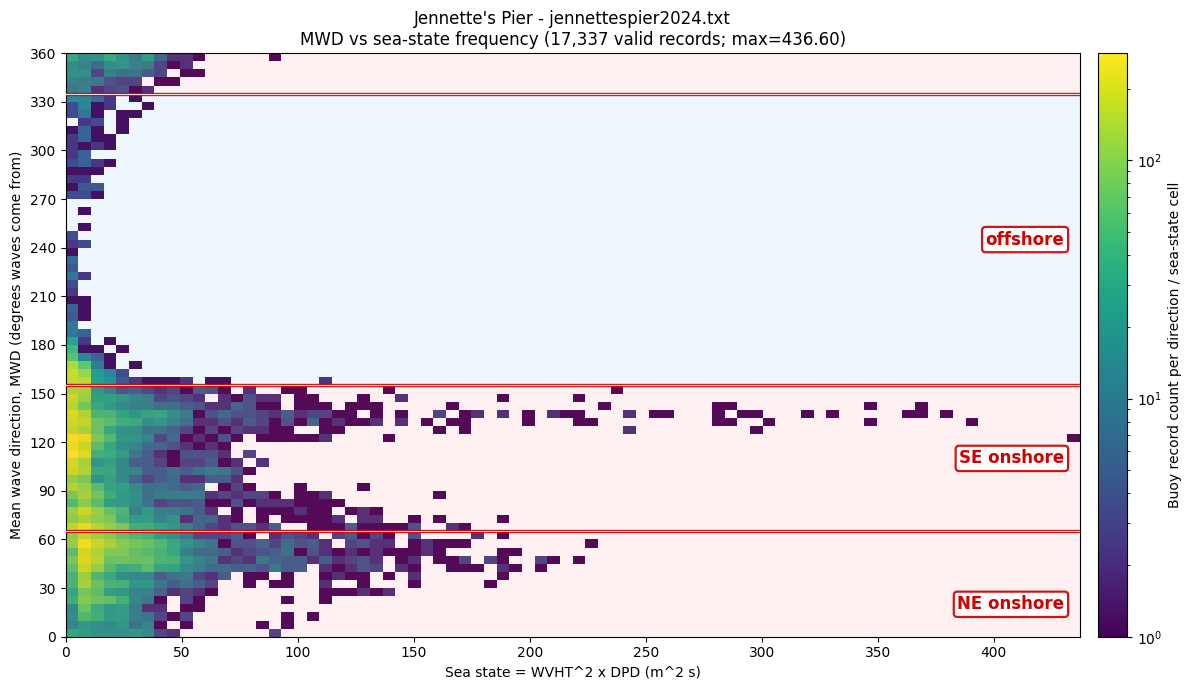

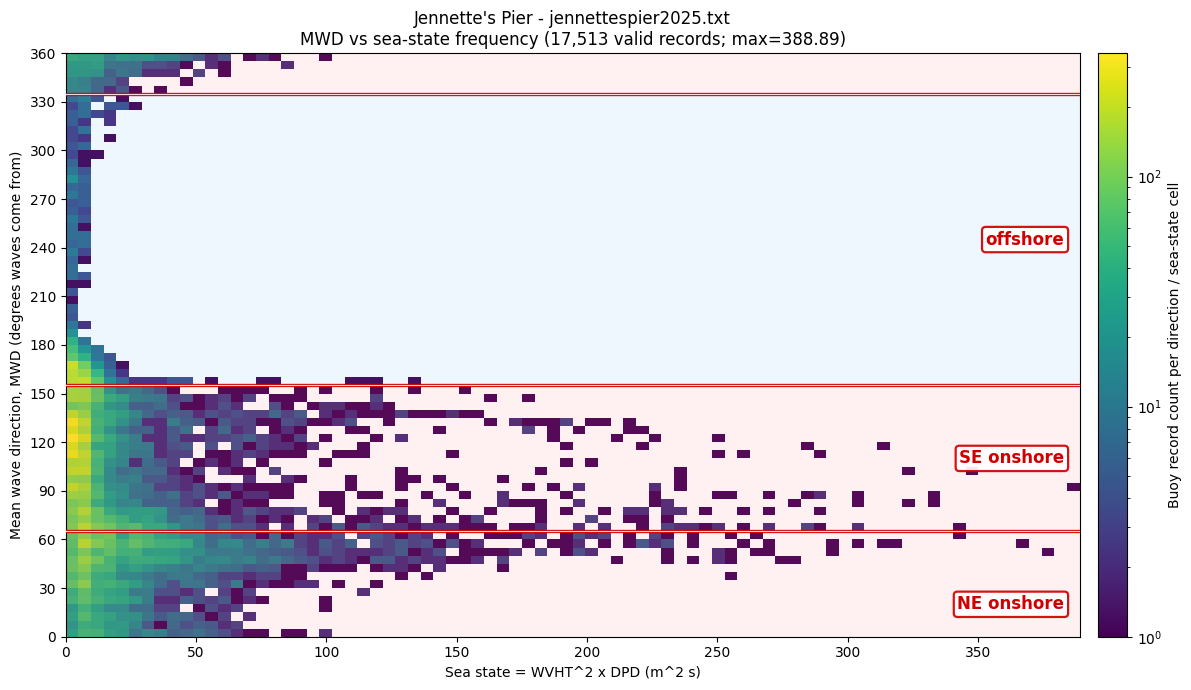

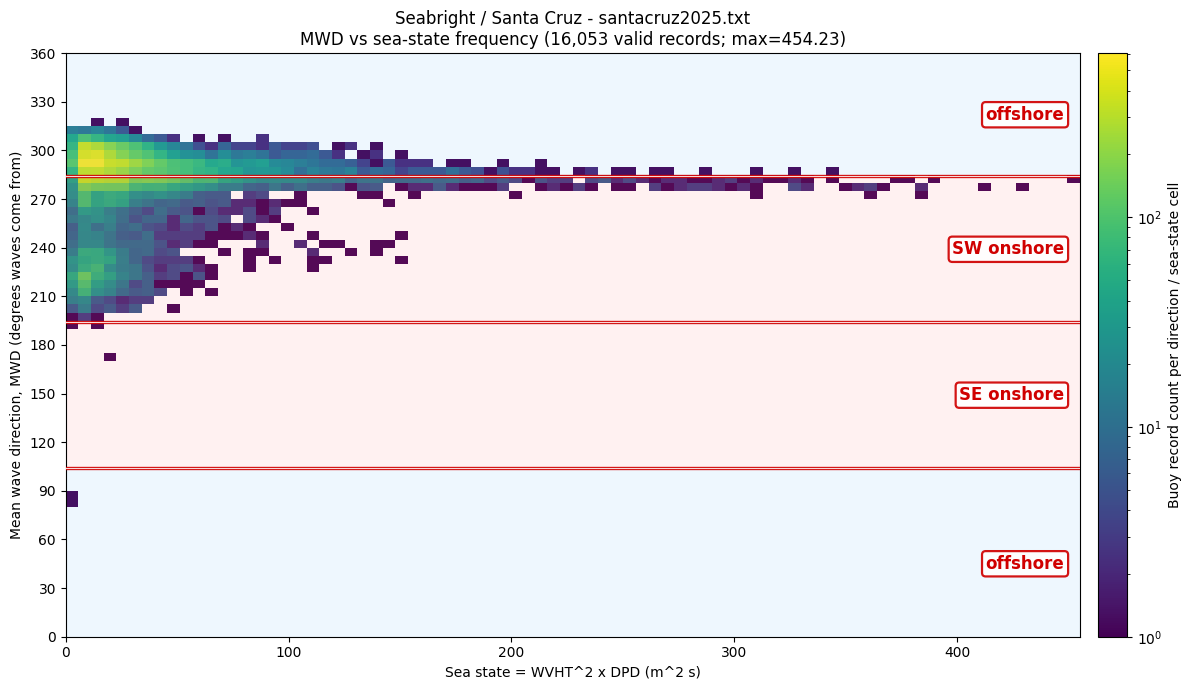

,dataset,output_path,occupied_cells,maximum_cell_count
0,jennettespier2024,C:\Users\monaz\Documents\GitHub\sam2_realtime\...,822,282
1,jennettespier2025,C:\Users\monaz\Documents\GitHub\sam2_realtime\...,994,344
2,santacruz2025,C:\Users\monaz\Documents\GitHub\sam2_realtime\...,501,604


In [4]:
def direction_spans(start, end):
    """Return one or two non-wrapping y-spans for a compass-direction range."""
    if start < end:
        return [(start, end)]
    return [(start, 360), (0, end)]


def group_display_label(direction_group, final_group):
    label = direction_group.replace('_', ' ')
    label = label.replace('north easterly', 'NE').replace('south easterly', 'SE')
    label = label.replace('south westerly', 'SW')
    return label


def draw_direction_group_guides(ax, config, x_max):
    band_colors = {
        'onshore': '#ff6b6b',
        'offshore': '#4dabf7',
        'all': '#adb5bd',
    }
    line_color = '#d00000'

    # Light horizontal bands make the direction areas visible even where the
    # heatmap has sparse white cells. Wrapped compass ranges are split into two.
    for direction_group, final_group, start, end in config['groups']:
        color = band_colors.get(final_group, '#adb5bd')
        for low, high in direction_spans(start, end):
            ax.axhspan(low, high, color=color, alpha=0.09, zorder=2, linewidth=0)

    # Strong red separators are intentionally drawn over the heatmap.
    for boundary in config['boundaries']:
        ax.axhline(boundary, color=line_color, linewidth=2.4, linestyle='-', alpha=0.95, zorder=5)
        ax.axhline(boundary, color='white', linewidth=0.8, linestyle='-', alpha=0.85, zorder=6)

    for y, label in config['labels']:
        ax.text(
            x_max * 0.985,
            y,
            label,
            ha='right',
            va='center',
            color=line_color,
            fontsize=12,
            fontweight='bold',
            zorder=7,
            bbox={
                'facecolor': 'white',
                'alpha': 0.92,
                'edgecolor': line_color,
                'linewidth': 1.6,
                'boxstyle': 'round,pad=0.22',
            },
        )


def plot_direction_sea_state_heatmap(name, item):
    frame = item['data']
    config = item['config']
    max_sea_state = float(frame['sea_state'].max())
    x_max = max(1.0, np.ceil(max_sea_state))
    sea_edges = np.linspace(0, x_max, SEA_STATE_BIN_COUNT + 1)
    direction_edges = np.arange(0, 360 + DIRECTION_BIN_DEGREES, DIRECTION_BIN_DEGREES)
    counts, _, _ = np.histogram2d(
        frame['MWD'].to_numpy(),
        frame['sea_state'].to_numpy(),
        bins=[direction_edges, sea_edges],
    )

    masked_counts = np.ma.masked_where(counts == 0, counts)
    fig, ax = plt.subplots(figsize=(13, 7))
    color_options = {'cmap': 'viridis'}
    if USE_LOG_COLOR and counts.max() > 1:
        color_options['norm'] = LogNorm(vmin=1, vmax=max(1, counts.max()))
    mesh = ax.pcolormesh(
        sea_edges, direction_edges, masked_counts, shading='auto', zorder=1, **color_options
    )

    draw_direction_group_guides(ax, config, x_max)

    colorbar = fig.colorbar(mesh, ax=ax, pad=0.015)
    colorbar.set_label('Buoy record count per direction / sea-state cell')
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 360)
    ax.set_yticks(np.arange(0, 361, 30))
    ax.set_xlabel('Sea state = WVHT^2 x DPD (m^2 s)')
    ax.set_ylabel('Mean wave direction, MWD (degrees waves come from)')
    ax.set_title(
        f"{config['display_name']} - {item['path'].name}\n"
        f"MWD vs sea-state frequency ({len(frame):,} valid records; max={max_sea_state:.2f})"
    )
    fig.tight_layout()
    output_path = OUTPUT_DIR / f'{name}_mwd_vs_sea_state_heatmap.png'
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return output_path, counts

heatmap_outputs = []
for name, item in datasets.items():
    output_path, counts = plot_direction_sea_state_heatmap(name, item)
    heatmap_outputs.append({
        'dataset': name,
        'output_path': str(output_path.resolve()),
        'occupied_cells': int((counts > 0).sum()),
        'maximum_cell_count': int(counts.max()),
    })

display(pd.DataFrame(heatmap_outputs))


## Onshore/offshore distribution summary

Use the maximum to describe the observed endpoint, but use the 95th/99th percentiles to describe typical upper ranges. A maximum based on one record should not be presented as a stable physical limit.

,dataset,site,final_plot_group,records,sea_state_median,sea_state_p95,sea_state_p99,sea_state_max
0,jennettespier2024,Jennette's Pier,offshore,1374,5.011,16.039,28.063,114.557
1,jennettespier2024,Jennette's Pier,onshore,15963,11.156,57.958,129.070,436.601
2,jennettespier2025,Jennette's Pier,offshore,1939,4.615,13.697,28.545,135.712
3,jennettespier2025,Jennette's Pier,onshore,15574,9.304,71.025,191.942,388.893
4,santacruz2025,Seabright / Santa Cruz,offshore,10314,19.949,84.651,147.906,454.231
5,santacruz2025,Seabright / Santa Cruz,onshore,5739,20.695,106.759,263.607,427.147


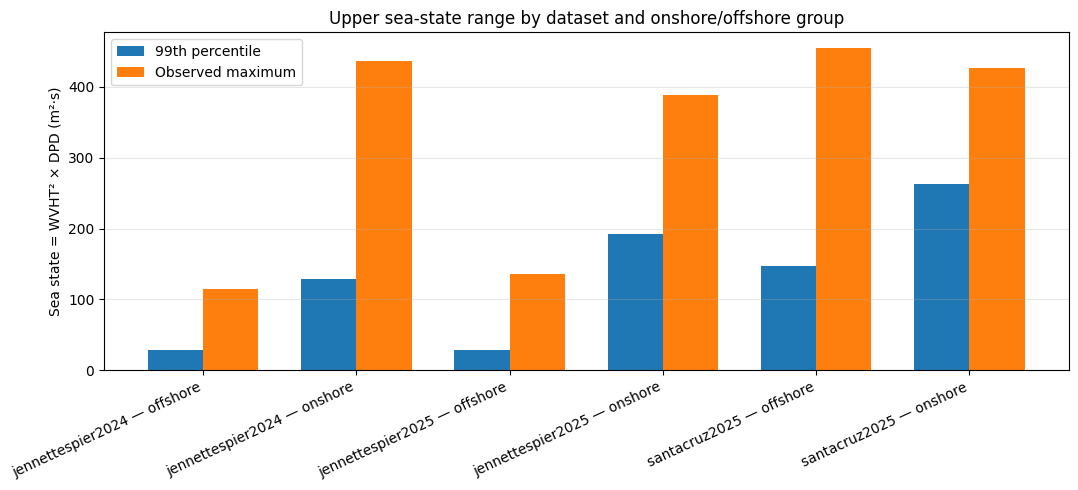

Saved summary plot: C:\Users\monaz\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\buoy_direction_sea_state_heatmaps\onshore_offshore_upper_sea_state_comparison.png


In [5]:
summary_rows = []
for name, item in datasets.items():
    frame = item['data']
    for final_group, group in frame.groupby('final_plot_group', dropna=False):
        values = group['sea_state'].dropna()
        if values.empty:
            continue
        summary_rows.append({
            'dataset': name,
            'site': item['config']['display_name'],
            'final_plot_group': final_group,
            'records': len(values),
            'sea_state_median': values.median(),
            'sea_state_p95': values.quantile(0.95),
            'sea_state_p99': values.quantile(0.99),
            'sea_state_max': values.max(),
        })

distribution_summary = pd.DataFrame(summary_rows).sort_values(
    ['dataset', 'final_plot_group']
).reset_index(drop=True)
distribution_summary.to_csv(OUTPUT_DIR / 'onshore_offshore_sea_state_summary.csv', index=False)
display(distribution_summary.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
plot_table = distribution_summary.copy()
plot_table['label'] = plot_table['dataset'] + ' — ' + plot_table['final_plot_group'].astype(str)
x = np.arange(len(plot_table))
width = 0.36
ax.bar(x - width / 2, plot_table['sea_state_p99'], width, label='99th percentile')
ax.bar(x + width / 2, plot_table['sea_state_max'], width, label='Observed maximum')
ax.set_xticks(x, plot_table['label'], rotation=25, ha='right')
ax.set_ylabel('Sea state = WVHT² × DPD (m²·s)')
ax.set_title('Upper sea-state range by dataset and onshore/offshore group')
ax.grid(axis='y', alpha=0.3)
ax.legend()
fig.tight_layout()
summary_plot_path = OUTPUT_DIR / 'onshore_offshore_upper_sea_state_comparison.png'
fig.savefig(summary_plot_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved summary plot:', summary_plot_path.resolve())